Summary: 

Import modules needed

In [5]:
import sdf_xarray as sdfxr
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import sys
import os
utility_path = os.path.expanduser("/home/pnd531/Desktop/Project_EPOCH/src/jupyter_utility")
if utility_path not in sys.path:
    sys.path.append(utility_path)

import lbw_utility as lbwu

We will use the test_ang_spectrum simulation as an example.

In [6]:
ds_2_fix= sdfxr.open_mfdataset("/home/pnd531/Desktop/Project_EPOCH/dev_test/test_laser_block/test_abs_frac_with_two_lasers/two_lasers_my_fix/*.sdf")
ds_1_fix = sdfxr.open_mfdataset("/home/pnd531/Desktop/Project_EPOCH/dev_test/test_laser_block/test_abs_frac_with_two_lasers/one_laser_fix/*.sdf")
ds_1  = sdfxr.open_mfdataset("/home/pnd531/Desktop/Project_EPOCH/dev_test/test_laser_block/test_abs_frac_with_two_lasers/one_laser/*.sdf")

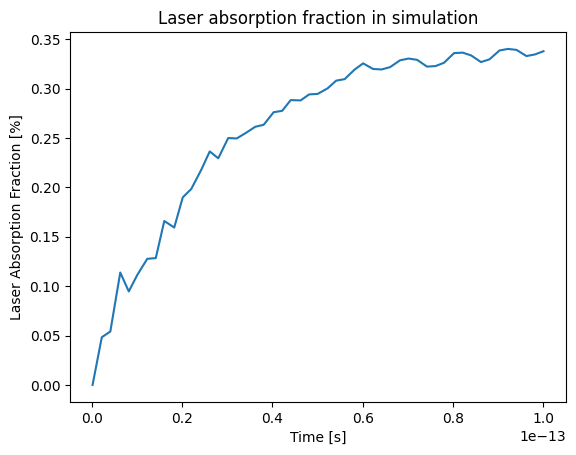

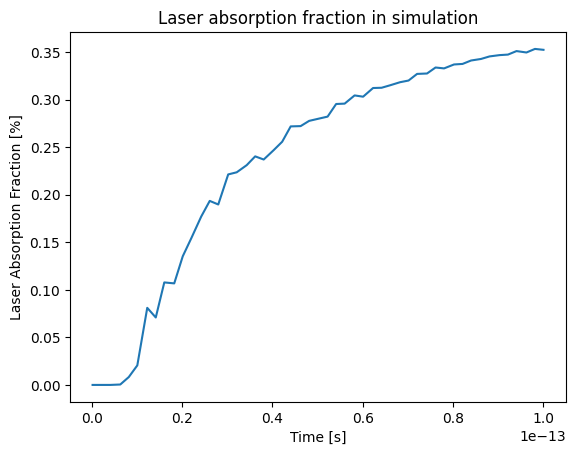

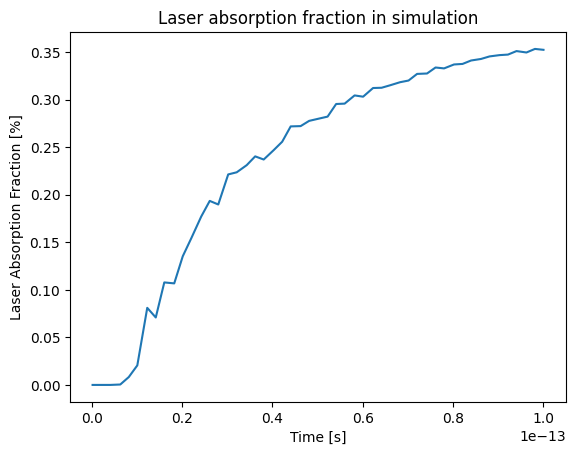

In [7]:
lbwu.plot_laser_abs_frac(ds_2_fix,does_save=False)
lbwu.plot_laser_abs_frac(ds_1_fix,does_save=False)
lbwu.plot_laser_abs_frac(ds_1,does_save=False)


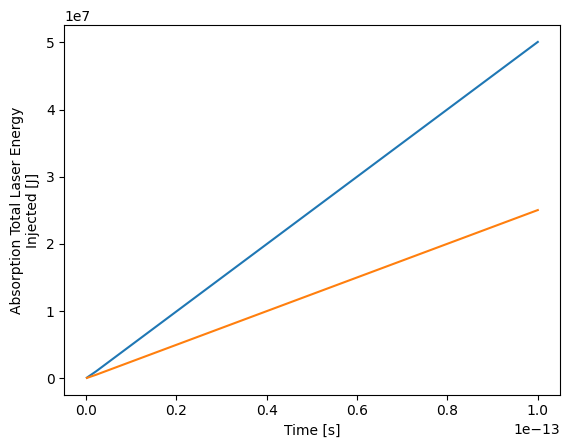

In [10]:
ds_2_fix["Absorption_Total_Laser_Energy_Injected"].plot()
ds_1_fix["Absorption_Total_Laser_Energy_Injected"].plot()


In [ ]:
lbwu.plot_laser_abs_frac(ds,does_save=False)

In [ ]:
anim=ds["Electric_Field_Ey"].epoch.animate()
anim.show()

In [ ]:
lbwu.plot_laser_abs_frac(ds)

To start with, let's animate the electron number density as an interactive window.

In [ ]:
ds.data_vars

In [ ]:
da = ds["Derived_Number_Density_ele_lbw"]
anim = da.epoch.animate()
anim.show()

We can take a lineout from 2D grid and plot the variable against x-coordinate.

In [ ]:
da = ds["Derived_Number_Density_Electron"]
da_lineout = da.sel(Y_Grid_mid = 1e-6, method = "nearest")
anim = da_lineout.epoch.animate(title = "Y = 1e-6 [m]")
anim.show()

Let's animate a 3D simulation. Be very careful about the file size and the memory of the PC! Load only the variables you need to save memory. Open the activity monitor and look at the memory used.

In [ ]:
ds = sdfxr.open_mfdataset("/home/pnd531/Desktop/data_depository/3d qed rese/*.sdf",data_vars=["Derived_Number_Density_Electron"])


We can take a y-slice to look at a variable in the z-x plane.

In [ ]:
da = ds["Derived_Number_Density_Electron"]
da_lineout = da.sel(Y_Grid_mid = 0, method="nearest")
anim = da_lineout.epoch.animate(title = "Y = 0 [m]", fps = 2)
anim.show()

We can also take a time slice and animate over one coordinate. For example, we take time index 20, animate over x, and plot a heatmap of electron number density on y-z grid:

In [ ]:

da = ds["Derived_Number_Density_Electron"].isel(time=20)
anim = da.epoch.animate(t = "X_Grid_mid")
anim.show()


Moving window.
This requires more input. Importantly, one needs to use xarray.open_mfdataset() to load sdf files. Putting join = "override" sometimes results in vertical banding. Changing that to "override" may resolve the issue. 

In [ ]:
ds = xr.open_mfdataset(
   "/home/pnd531/Desktop/Project_EPOCH/dev_test/test_moving_window_workshop/sdf_files/*.sdf",
   preprocess = sdfxr.SDFPreprocess(),
   combine = "nested",
   join = "override",
   compat="no_conflicts",
   concat_dim="time",
   )

da = ds["Derived_Number_Density_electron"]
anim = da.epoch.animate(move_window=True, fps = 5)
anim.show()

Customisation. We can convert units, change variable names, change colour setting, etc.

In [ ]:
ds= sdfxr.open_mfdataset("/home/pnd531/Desktop/Project_EPOCH/dev_test/test_ang_spectrum/sdf_files/*.sdf")

In [ ]:
# Change the units of the coordinates
ds = ds.epoch.rescale_coords(1e6, "µm", ["X_Grid_mid", "Y_Grid_mid"])
ds = ds.epoch.rescale_coords(1e15, "fs", ["time"])
ds["time"].attrs["long_name"] = "t"

# Change units and name of the variable
da = ds["Derived_Number_Density_Electron"]
da.data = da.values * 1e-6
da.attrs["units"] = "cm$^{-3}$"
da.attrs["long_name"] = "$n_e$"

anim = da.epoch.animate(
   fps = 2,
   max_percentile = 95,
   title = "Target A",
   cmap = "plasma",
   )
anim.show()

Multiple animation.

In [ ]:
import numpy as np
from matplotlib.colors import LogNorm

flux_magnitude = np.sqrt(
   ds["Derived_Poynting_Flux_x"]**2 +
   ds["Derived_Poynting_Flux_y"]**2 +
   ds["Derived_Poynting_Flux_z"]**2
)
flux_magnitude.attrs["long_name"] = "Poynting Flux Magnitude"
flux_magnitude.attrs["units"] = "W/m$^2$"

# Cut-off low energy values so that they will be rendered as transparent
# in the plot as they've been set to NaN
flux_masked = flux_magnitude.where(flux_magnitude > 0.2e23)
flux_norm = LogNorm(
   vmin=float(flux_masked.min()),
   vmax=float(flux_masked.max())
)

anim = ds.epoch.animate_multiple(
   ds["Derived_Number_Density_Electron"],
   flux_masked,
   datasets_kwargs=[
      {"alpha": 1.0},
      {"cmap": "hot", "norm": flux_norm, "alpha": 0.8},
   ],
)
anim.show()

In [ ]:


anim = ds.epoch.animate_multiple(
   ds["Derived_Number_Density_Electron"],
   flux_masked,
   datasets_kwargs=[
      {"alpha": 1.0},
      {"cmap": "hot", "norm": flux_norm, "alpha": 0.8},
   ],
)
anim.show()